<a href="https://colab.research.google.com/github/Sabharishraja/AD23633_Generative-AI/blob/main/Exp_3_GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

In [ ]:
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5 # Normalize to [-1, 1]
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

In [ ]:
batch_size = 64
noise_dim = 100
epochs = 10

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(batch_size)

In [ ]:
generator = keras.Sequential([
 keras.layers.Input(shape=(noise_dim,)),
 keras.layers.Dense(128, activation='relu'),
 keras.layers.Dense(28 * 28 * 1, activation='tanh'),
 keras.layers.Reshape((28, 28, 1))
])

In [ ]:
discriminator = keras.Sequential([
 keras.layers.Input(shape=(28, 28, 1)),
 keras.layers.Flatten(),
 keras.layers.Dense(128, activation='relu'),
 keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
loss_fn = keras.losses.BinaryCrossentropy()
g_optimizer = keras.optimizers.Adam(learning_rate=0.0002)
d_optimizer = keras.optimizers.Adam(learning_rate=0.0002)

In [ ]:
for epoch in range(epochs):
    for real_images in dataset:
        batch_size_now = real_images.shape[0]
        real_labels = tf.ones((batch_size_now, 1))
        fake_labels = tf.zeros((batch_size_now, 1))
        noise = tf.random.normal((batch_size_now, noise_dim))
        fake_images = generator(noise, training=True)

        with tf.GradientTape() as tape:
            real_output = discriminator(real_images, training=True)
            fake_output = discriminator(fake_images, training=True)
            real_loss = loss_fn(real_labels, real_output)
            fake_loss = loss_fn(fake_labels, fake_output)
            d_loss = real_loss + fake_loss
        d_gradients = tape.gradient(d_loss, discriminator.trainable_variables)
        d_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))

        noise = tf.random.normal((batch_size_now, noise_dim))
        with tf.GradientTape() as tape:
            generated_images = generator(noise, training=True)
            output = discriminator(generated_images, training=True)
            g_loss = loss_fn(real_labels, output)
        g_gradients = tape.gradient(g_loss, generator.trainable_variables)
        g_optimizer.apply_gradients(zip(g_gradients, generator.trainable_variables))

    print(f"Epoch [{epoch+1}/{epochs}] D Loss: {d_loss.numpy():.4f} G Loss: {g_loss.numpy():.4f}")

Epoch [1/10] D Loss: 0.4302 G Loss: 1.6391
Epoch [2/10] D Loss: 0.4683 G Loss: 1.6802
Epoch [3/10] D Loss: 0.8260 G Loss: 1.1514
Epoch [4/10] D Loss: 0.3020 G Loss: 1.9980
Epoch [5/10] D Loss: 1.1264 G Loss: 1.1468
Epoch [6/10] D Loss: 0.7178 G Loss: 1.3459
Epoch [7/10] D Loss: 0.3455 G Loss: 2.1533
Epoch [8/10] D Loss: 0.9227 G Loss: 1.5367
Epoch [9/10] D Loss: 0.7245 G Loss: 1.9272
Epoch [10/10] D Loss: 0.3122 G Loss: 2.7105


In [ ]:
noise = tf.random.normal((16, noise_dim))
generated_images = generator(noise, training=False)

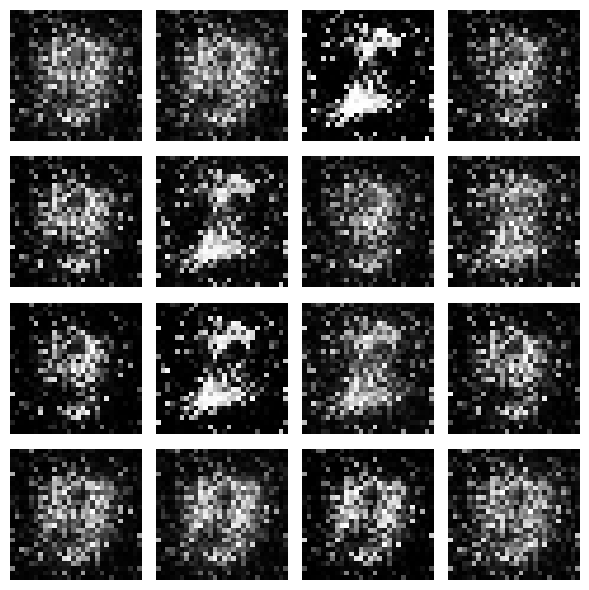

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow((generated_images[i, :, :, 0] + 1) / 2, cmap='gray')
    ax.axis("off")
plt.tight_layout()
plt.show()